In [8]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [9]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 - Level/Greece/data/'

In [10]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [11]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [12]:
df.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new,rainfall
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-01-01,2024,1,2023-12-29,41.27085,24.027688,0.368172,0.003854,-0.363517,-0.003854,0.380931,-0.031265,-0.388055,0.031265,0.030337,0.049374,0.021094,0.049374,2024-01-01,41.27085,24.027688,14231.0,13802.0,2024-01-01,41.250189,24.05011,2023-12-31,2024-04-28,0.001276,NaN
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-01-02,2024,1,2023-12-29,41.27085,24.027688,0.368172,0.003854,-0.363517,-0.003854,0.380931,-0.031265,-0.388055,0.031265,0.030337,0.049374,0.021094,0.049374,2024-01-02,41.27085,24.027688,14231.0,13852.0,2024-01-02,41.250189,24.05011,2024-01-01,2024-01-01,0.184626,NaN
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-01-03,2024,1,2024-01-03,41.27085,24.027688,0.368172,0.003854,-0.363517,-0.003854,0.380931,-0.031265,-0.388055,0.031265,0.030337,0.049374,0.021094,0.049374,2024-01-03,41.27085,24.027688,14231.0,13837.0,2024-01-03,41.250189,24.05011,2024-01-02,2024-01-02,0.246383,NaN
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-01-04,2024,1,2024-01-03,41.27085,24.027688,0.368172,0.003854,-0.363517,-0.003854,0.380931,-0.031265,-0.388055,0.031265,0.030337,0.049374,0.021094,0.049374,2024-01-04,41.27085,24.027688,14089.0,13903.0,2024-01-04,41.250189,24.05011,2024-01-03,2024-01-03,0.000000,NaN
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-01-05,2024,1,2024-01-03,41.27085,24.027688,0.368172,0.003854,-0.363517,-0.003854,0.380931,-0.031265,-0.388055,0.031265,0.030337,0.049374,0.021094,0.049374,2024-01-05,41.27085,24.027688,13918.0,13903.0,2024-01-05,41.250189,24.05011,2024-01-04,2024-01-04,0.000000,NaN


In [13]:
df['dt_placement'] = pd.to_datetime(df['dt_placement'])
df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Text(0.5, 1.0, 'Year: 2024')

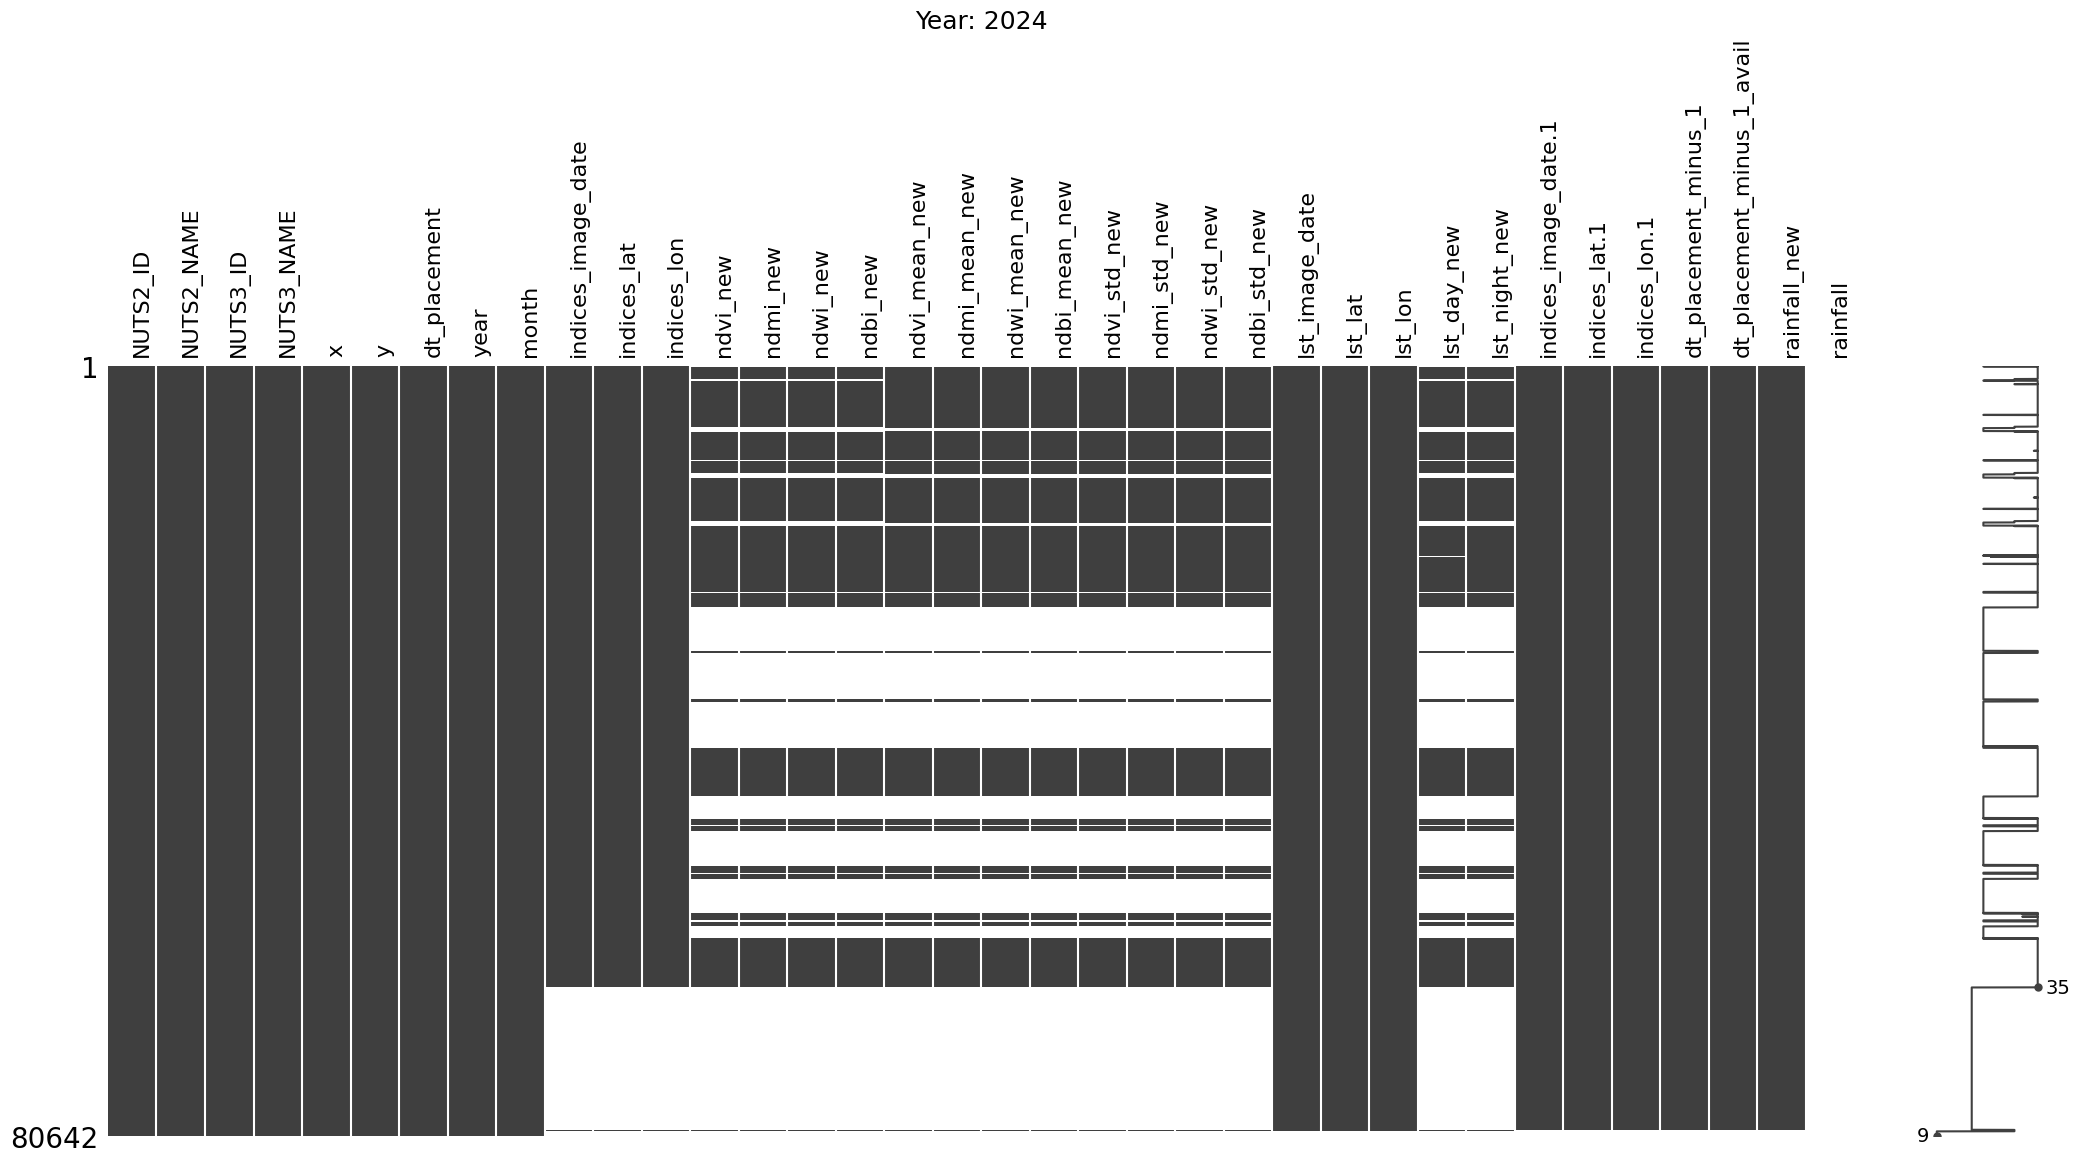

In [14]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [10]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,0.0106
13,ndmi_new,0.0106
14,ndwi_new,0.0106
15,ndbi_new,0.0106
16,ndvi_mean_new,0.0012
17,ndmi_mean_new,0.0012
18,ndwi_mean_new,0.0012
19,ndbi_mean_new,0.0130
20,ndvi_std_new,0.0012
21,ndmi_std_new,0.0012


In [11]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [12]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,0.0106
11,ndmi,0.0106
12,ndwi,0.0106
13,ndbi,0.0106
14,ndvi_mean,0.0012
15,ndmi_mean,0.0012
16,ndwi_mean,0.0012
17,ndbi_mean,0.0130
18,ndvi_std,0.0012
19,ndmi_std,0.0012


In [13]:
df2 = df.copy()

In [14]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [15]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,0.0106
11,ndmi,0.0106
12,ndwi,0.0106
13,ndbi,0.0106
14,ndvi_mean,0.0012
15,ndmi_mean,0.0012
16,ndwi_mean,0.0012
17,ndbi_mean,0.0130
18,ndvi_std,0.0012
19,ndmi_std,0.0012


In [16]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [17]:
df2.reset_index(drop=True, inplace=True)

In [18]:
df2

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13689.0,1.164514
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,11.846938
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,0.714449
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13834.0,0.000000
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.0,13678.0,0.250432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84663,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.31112,2024-05-01,2024,5,0.657875,0.377295,-0.567324,-0.377295,0.533775,0.229863,-0.484205,-0.229863,0.091889,0.106971,0.061969,0.106971,NaN,NaN,NaN
84664,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.27518,2024-05-01,2024,5,0.377570,0.176377,-0.317248,-0.176377,0.412067,0.206542,-0.339813,-0.206542,0.041501,0.030382,0.038669,0.030382,NaN,NaN,NaN
84665,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.23925,2024-05-01,2024,5,0.318741,0.115418,-0.321000,-0.115418,0.357992,0.105538,-0.354827,-0.105538,0.111367,0.083026,0.085742,0.083026,NaN,NaN,NaN
84666,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.16738,2024-05-01,2024,5,0.377635,0.153777,-0.372142,-0.153777,0.344275,0.125509,-0.362614,-0.125509,0.035156,0.029671,0.018951,0.029671,NaN,NaN,NaN


Text(0.5, 1.0, 'Year: 2024')

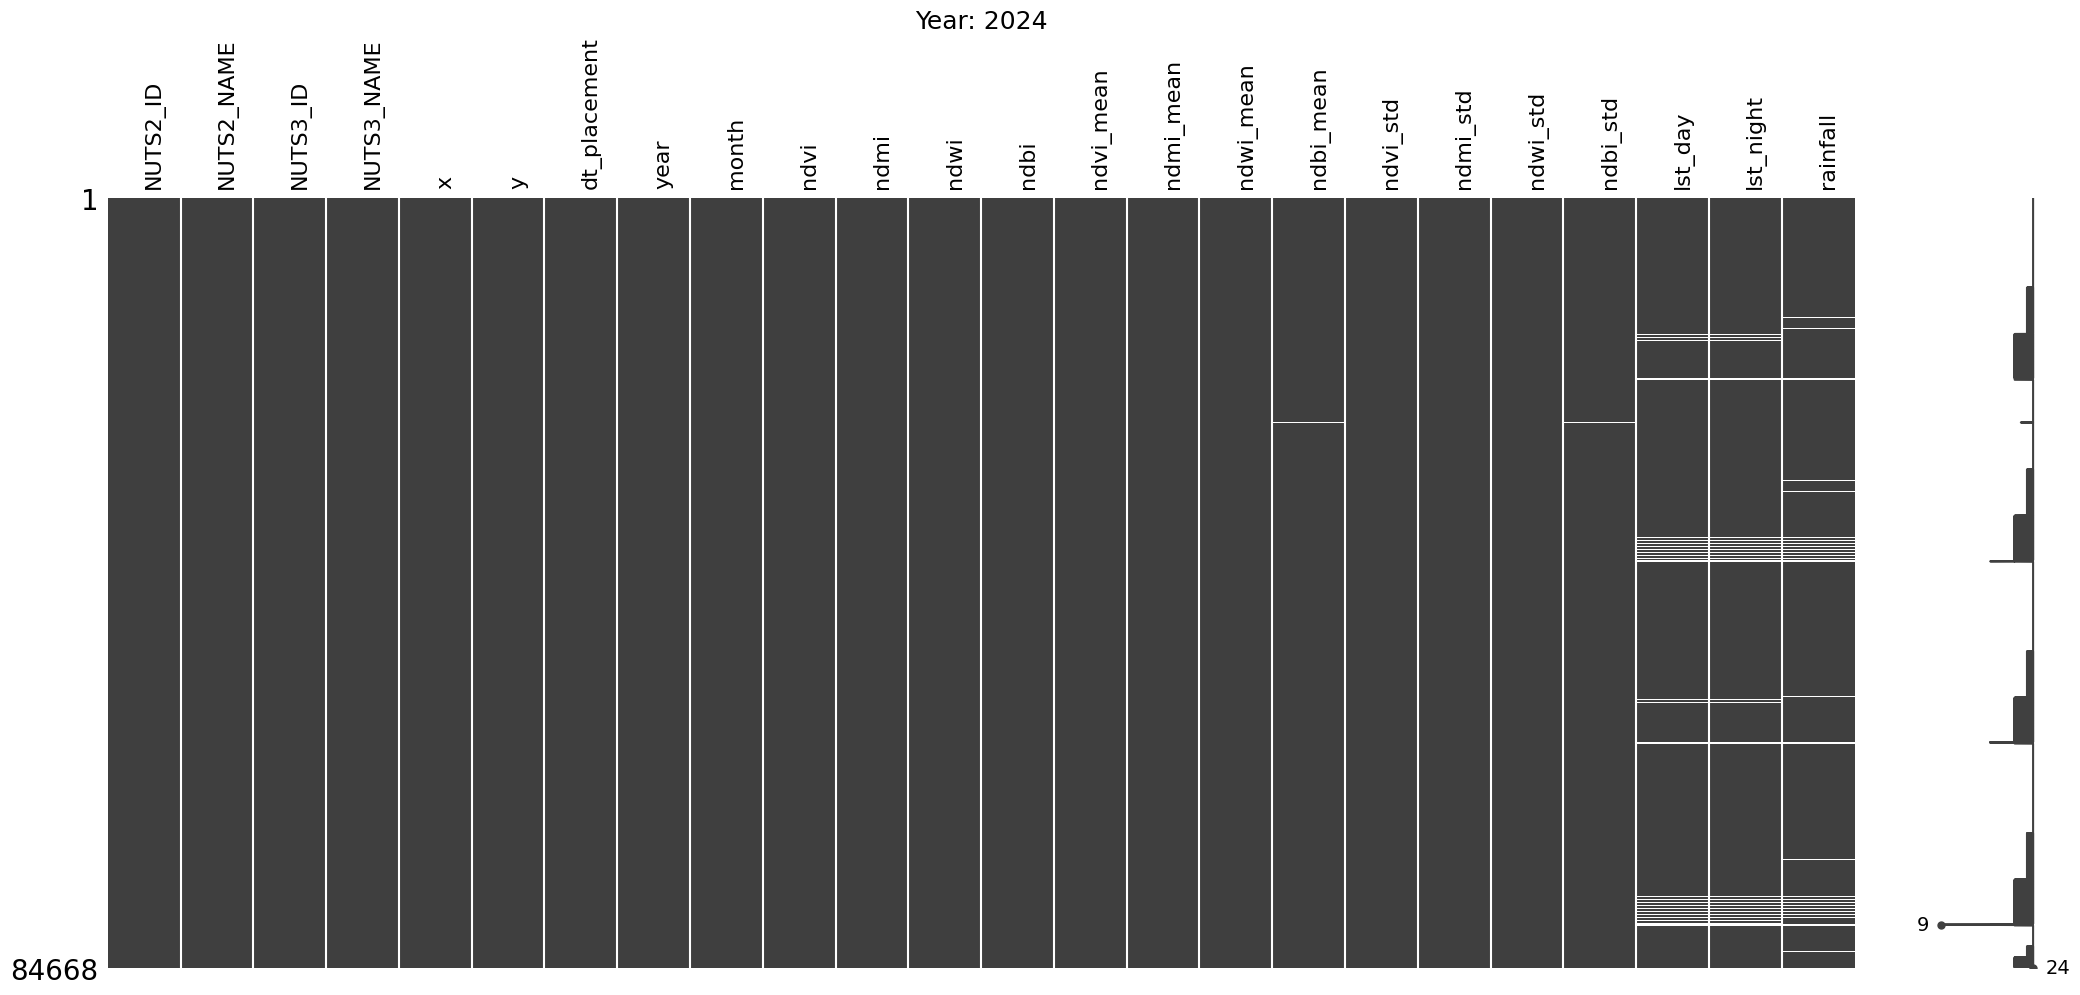

In [19]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [20]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')